In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
import os
import numpy as np
from PIL import Image


✅ history_fold_1.png -> ukuran setelah crop: 1188x386
✅ history_fold_2.png -> ukuran setelah crop: 1188x386
✅ history_fold_3.png -> ukuran setelah crop: 1188x386
✅ history_fold_4.png -> ukuran setelah crop: 1188x386
✅ history_fold_5.png -> ukuran setelah crop: 1188x386
Rata-rata rasio lebar/tinggi: 3.08
Margin: left=-0.236, right=1.236, bottom=0.266, top=0.734
✅ Gambar berhasil disimpan sebagai '5Fold_CrossValidation_Final.png'


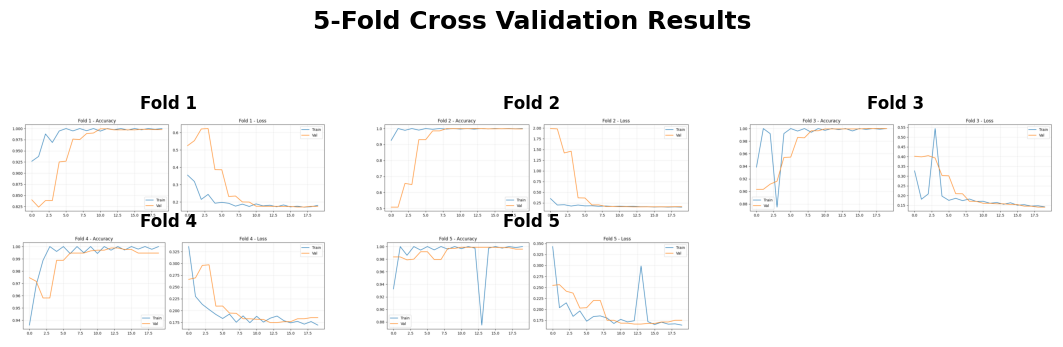

In [6]:


# ===== KONFIGURASI UKURAN (dalam cm) =====
lebar_total_cm = 18    # lebar gambar jadi
tinggi_total_cm = 12   # tinggi gambar jadi
# =========================================

files = [
    "history_fold_1.png",
    "history_fold_2.png",
    "history_fold_3.png",
    "history_fold_4.png",
    "history_fold_5.png"
]

# ----- Fungsi crop otomatis (lebih agresif) -----
def crop_borders(img_np, threshold=30):
    """Potong pinggiran putih dan teks pinggir dengan threshold lebih tinggi."""
    if img_np.ndim == 3:
        gray = np.mean(img_np, axis=2)
    else:
        gray = img_np
    rows = np.where(np.any(gray < threshold, axis=1))[0]
    cols = np.where(np.any(gray < threshold, axis=0))[0]
    if len(rows) == 0 or len(cols) == 0:
        return img_np
    # Tambahkan potongan ekstra untuk menghilangkan teks di pinggir (misal 10 pixel)
    r1 = max(0, rows[0] - 10)
    r2 = min(img_np.shape[0], rows[-1] + 10)
    c1 = max(0, cols[0] - 10)
    c2 = min(img_np.shape[1], cols[-1] + 10)
    return img_np[r1:r2, c1:c2]

# ----- Baca dan crop gambar -----
images = []
aspect_ratios = []
for f in files:
    if not os.path.exists(f):
        print(f"❌ File {f} tidak ditemukan!")
        exit()
    img = Image.open(f)
    if img.mode == 'RGBA':
        img = img.convert('RGB')
    img_np = np.array(img)
    img_np = crop_borders(img_np, threshold=35)  # threshold tinggi
    images.append(img_np)
    h, w = img_np.shape[:2]
    aspect_ratios.append(w / h)
    print(f"✅ {f} -> ukuran setelah crop: {w}x{h}")

avg_aspect = np.mean(aspect_ratios)
print(f"Rata-rata rasio lebar/tinggi: {avg_aspect:.2f}")

# ----- Hitung ukuran figure (dalam inci) -----
lebar_inch = lebar_total_cm / 2.54
tinggi_inch = tinggi_total_cm / 2.54

# Layout 2 baris x 3 kolom, dengan spasi yang cukup
wspace = 0.15   # spasi horizontal
hspace = 0.15   # spasi vertikal

# Cari ukuran subplot maksimum yang muat
sh = tinggi_inch / 2.5
for _ in range(20):
    sw = sh * avg_aspect
    total_w = 3 * sw + 2 * wspace * sw
    total_h = 2 * sh + hspace * sh
    margin_w = 0.06 * lebar_inch
    margin_h = 0.12 * tinggi_inch  # untuk judul dan margin bawah
    if total_w + margin_w > lebar_inch or total_h + margin_h > tinggi_inch:
        sh *= 0.97
    else:
        sh *= 1.02

sw = sh * avg_aspect
total_w = 3 * sw + 2 * wspace * sw
total_h = 2 * sh + hspace * sh

# Posisi subplot agar terpusat
left_margin = (lebar_inch - total_w) / (2 * lebar_inch)
right_margin = 1 - left_margin
bottom_margin = (tinggi_inch - total_h) / (2 * tinggi_inch)
top_margin = 1 - bottom_margin

# Pastikan ada ruang untuk judul
if top_margin < 0.10:
    top_margin = 0.10
    bottom_margin = 1 - top_margin

print(f"Margin: left={left_margin:.3f}, right={right_margin:.3f}, bottom={bottom_margin:.3f}, top={top_margin:.3f}")

# ----- Buat figure dan grid -----
fig = plt.figure(figsize=(lebar_inch, tinggi_inch))
gs = fig.add_gridspec(2, 3, wspace=wspace, hspace=hspace,
                      left=left_margin, right=right_margin,
                      bottom=bottom_margin, top=top_margin)

axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    axes.append(ax)

for i in range(5):
    ax = axes[i]
    ax.imshow(images[i])   # aspect='equal'
    ax.set_title(f"Fold {i+1}", fontsize=12, fontweight='bold', pad=6)
    ax.axis('off')

axes[5].axis('off')

plt.suptitle("5-Fold Cross Validation Results", fontsize=18, fontweight='bold', y=0.96)

plt.savefig("5Fold_CrossValidation_Final.png", dpi=300, bbox_inches='tight', pad_inches=0.02)
print("✅ Gambar berhasil disimpan sebagai '5Fold_CrossValidation_Final.png'")
plt.show()